<a href="https://colab.research.google.com/github/ellensalua/ellenpunyatugas1web/blob/main/TUBES_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORT LIBRARY

import numpy as np
import pandas as pd


import sklearn as skl
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
# LOAD DATASET DARI GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive')

file_path ="/content/drive/MyDrive/projek tubes datasains/Jumlah Kunjungan Wisatawan Mancanegara per bulan Menurut Kebangsaan betul , 2025.csv"      #ganti dataset masing2

df = pd.read_csv(file_path)

print("Data Awal :")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data Awal :


,Asal_Negara,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
0,Malaysia,221474.0,214605.0,159895,170018,238497.0,236417,212113,229726,272421,234384,207037,243162,2639749
1,Singapore,NaN,89757.0,100883,97506,126391.0,183748,114224,129864,119237,123578,126254,204512,1526438
2,Timor Leste,75735.0,61770.0,63471,69721,80809.0,82296,90840,89516,86861,90077,98987,119098,1009181
3,Indonesia,46451.0,42534.0,35310,45118,51180.0,69252,55391,62962,54550,58476,50980,59812,632016
4,Philippines,16370.0,15505.0,15457,18652,23264.0,24580,22132,22278,20437,22948,22054,23051,246728


STEP 1 DATA CLEANING

In [ ]:
#menhapus kolom tahunan
df = df.drop(columns=["Tahunan"])
df.head()

,Asal_Negara,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,Malaysia,221474.0,214605.0,159895,170018,238497.0,236417,212113,229726,272421,234384,207037,243162
1,Singapore,NaN,89757.0,100883,97506,126391.0,183748,114224,129864,119237,123578,126254,204512
2,Timor Leste,75735.0,61770.0,63471,69721,80809.0,82296,90840,89516,86861,90077,98987,119098
3,Indonesia,46451.0,42534.0,35310,45118,51180.0,69252,55391,62962,54550,58476,50980,59812
4,Philippines,16370.0,15505.0,15457,18652,23264.0,24580,22132,22278,20437,22948,22054,23051


In [ ]:
#hapus data yang bukan negara
non_negara = [
    "Other Asia",
    "Other West Europe",
    "Other East Europe",
    "Central America",
    "South America",
    "Other America",
    "TOTAL OCEANIA",
    "A S E A N",
    "Other Oceania"
]

df = df[~df["Asal_Negara"].isin(non_negara)]

df.head()

,Asal_Negara,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,Malaysia,221474.0,214605.0,159895,170018,238497.0,236417,212113,229726,272421,234384,207037,243162
1,Singapore,NaN,89757.0,100883,97506,126391.0,183748,114224,129864,119237,123578,126254,204512
2,Timor Leste,75735.0,61770.0,63471,69721,80809.0,82296,90840,89516,86861,90077,98987,119098
3,Indonesia,46451.0,42534.0,35310,45118,51180.0,69252,55391,62962,54550,58476,50980,59812
4,Philippines,16370.0,15505.0,15457,18652,23264.0,24580,22132,22278,20437,22948,22054,23051


In [ ]:
#menyimpan file yg sdh di bersihkan
df.to_csv("/content/drive/MyDrive/projek tubes datasains/step1_dataset_rapi.csv", index=False)

STEP 2 MELAKUKAN MISING VALUE

In [ ]:
#cek mising value
df.isnull().sum()

,0
Asal_Negara,0
Januari,2
Februari,2
Maret,0
April,0
Mei,1
Juni,0
Juli,0
Agustus,0
September,0


In [ ]:
#handle mising value
df = df.fillna(0)

In [ ]:
#cek lagi mising valuenya
df.isnull().sum()

,0
Asal_Negara,0
Januari,0
Februari,0
Maret,0
April,0
Mei,0
Juni,0
Juli,0
Agustus,0
September,0


STEP 3Melakukan normalisasi data

In [ ]:
# pisahkan fitur
X = df.drop('Asal_Negara', axis=1)

In [ ]:
#normalisasi data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#ubah data frame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df['Asal_Negara'] = df['Asal_Negara']

X_scaled_df.head()

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Asal_Negara
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Malaysia
1,0.000000,0.418243,0.630933,0.573504,0.529948,0.777220,0.538505,0.565300,0.437694,0.527246,0.609814,0.841052,Singapore
2,0.341959,0.287831,0.396954,0.410080,0.338826,0.348097,0.428262,0.389664,0.318848,0.384314,0.478113,0.489789,Timor Leste
3,0.209736,0.198197,0.220832,0.265372,0.214594,0.292923,0.261139,0.274074,0.200242,0.249488,0.246236,0.245976,Indonesia
4,0.073914,0.072249,0.096670,0.109706,0.097544,0.103969,0.104341,0.096976,0.075020,0.097908,0.106522,0.094797,Philippines


In [ ]:
X_scaled_df.to_csv("/content/drive/MyDrive/projek tubes datasains/step4_normalisasi.csv", index=False)

In [ ]:
X_scaled_df.describe()

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
count,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000
mean,0.020510,0.020665,0.026905,0.029925,0.023927,0.026197,0.030568,0.028701,0.022421,0.025178,0.025332,0.025264
std,0.092267,0.088761,0.106060,0.114242,0.098509,0.107020,0.113342,0.107062,0.092513,0.100766,0.103410,0.108034
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000018,0.000015,0.000031,0.000031,0.000017,0.000038,0.000038,0.000026,0.000026,0.000030,0.000039,0.000029
50%,0.000199,0.000203,0.000288,0.000312,0.000226,0.000266,0.000413,0.000346,0.000283,0.000335,0.000314,0.000261
75%,0.003890,0.004544,0.006235,0.006305,0.004146,0.004264,0.005265,0.005265,0.004051,0.005082,0.005204,0.004907
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


MELAKUKAN EDA

In [ ]:
# total kunjungan per negara
total_per_negara = df.groupby('Asal_Negara').sum(numeric_only=True)
total_per_negara['Total'] = total_per_negara.sum(axis=1)

total_per_negara = total_per_negara.sort_values(by='Total', ascending=False)

total_per_negara.head(10)

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Total
Asal_Negara,,,,,,,,,,,,,
Malaysia,221474.0,214605.0,159895,170018,238497.0,236417,212113,229726,272421,234384,207037,243162,2639749.0
Australia,145563.0,105389.0,111032,149694,147650.0,154220,173241,155728,163526,158665,135215,154868,1754791.0
Singapore,0.0,89757.0,100883,97506,126391.0,183748,114224,129864,119237,123578,126254,204512,1415954.0
Tiongkok,111226.0,89302.0,84497,106553,114706.0,113520,144531,140667,113264,119617,105505,100686,1344074.0
Timor Leste,75735.0,61770.0,63471,69721,80809.0,82296,90840,89516,86861,90077,98987,119098,1009181.0
India,47600.0,49028.0,54564,61694,84381.0,80992,59775,54902,55809,55387,57486,72872,734490.0
Indonesia,46451.0,42534.0,35310,45118,51180.0,69252,55391,62962,54550,58476,50980,59812,632016.0
South Korea,47814.0,39362.0,27278,33281,38581.0,41529,54261,49382,41605,46778,38153,38838,496862.0
United Kingdom,26507.0,25269.0,33623,40946,36877.0,36189,43372,43868,35006,34337,26157,30751,412902.0


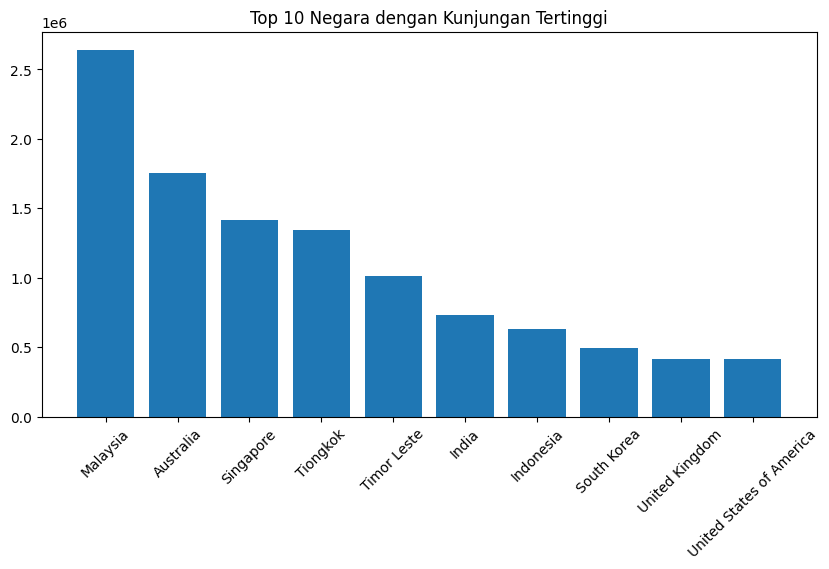

In [ ]:
# visualiasi

top10 = total_per_negara.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10['Total'])
plt.xticks(rotation=45)
plt.title("Top 10 Negara dengan Kunjungan Tertinggi")
plt.show()


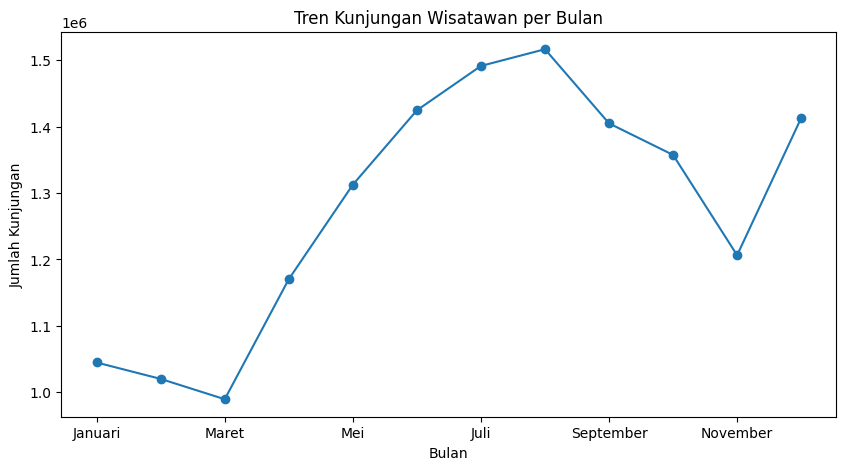

In [ ]:
monthly = df.drop(columns=['Asal_Negara']).sum()

monthly.plot(kind='line', marker='o', figsize=(10,5))
plt.title("Tren Kunjungan Wisatawan per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Kunjungan")
plt.show()

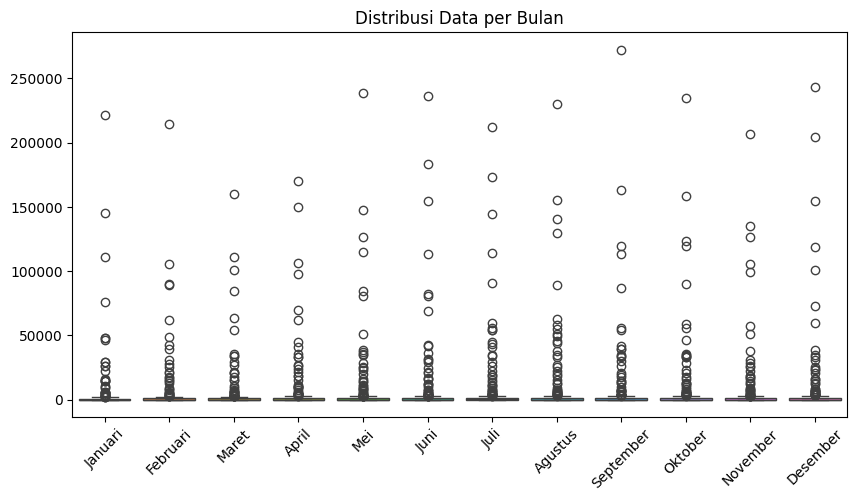

In [ ]:
# distribusi data
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop(columns=['Asal_Negara']))
plt.xticks(rotation=45)
plt.title("Distribusi Data per Bulan")
plt.show()

JALANKAN K MEANS

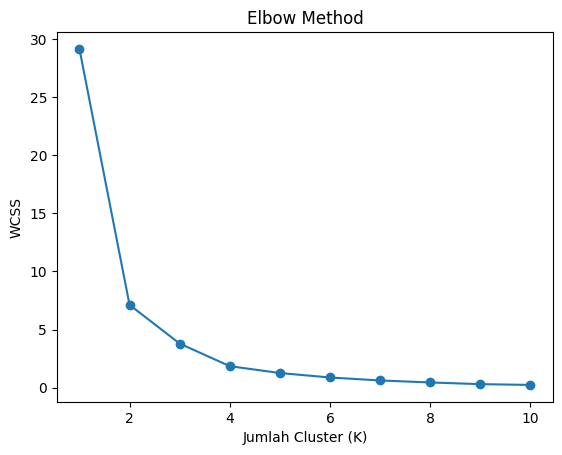

In [ ]:
wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [ ]:
# jalankan k means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

In [ ]:
# simpan hasil cluster
df['Cluster'] = labels

df[['Asal_Negara', 'Cluster']].head()

,Asal_Negara,Cluster
0,Malaysia,2
1,Singapore,2
2,Timor Leste,0
3,Indonesia,0
4,Philippines,0


In [ ]:
# isi tiap cluster
for i in range(3):
    print(f"\nCluster {i}:")
    print(df[df['Cluster'] == i]['Asal_Negara'].values)


Cluster 0:
['Timor Leste' 'Indonesia' 'Philippines' 'India' 'South Korea' 'Japan'
 'Lain-lain' 'United Kingdom' 'France' 'Germany' 'Netherlands'
 'United States of America']

Cluster 1:
['Thailand' 'Vietnam' 'Myanmar/Burma' 'Brunei Darussalam' 'Kamboja' 'Laos'
 'Turki' 'Mongolia' 'Kazakhstan' 'Pakistan' 'Uzbekistan' 'Bangladesh'
 'Nepal' 'Srilanka' 'Maladewa' 'Kirgistan' 'Tajikhistan' 'Bhutan'
 'Afganistan' 'Turkmenistan' 'Stateless' 'Korea Utara'
 'British Indian Ocean Teritory' 'Saudi Arabia' 'Oman' 'Egypt' 'Jordan'
 'Uni Emirat Arab' 'Yaman' 'Other Middle East' 'Iran' 'Kuwait' 'Irak'
 'Syiria' 'Palestina' 'Libanon' 'Bahrain' 'Qatar' 'Israel' 'R u s i a'
 'I t a l y' 'Spain' 'Polandia' 'Ukraine' 'Sweden' 'Denmark' 'Switzerland'
 'Portugal' 'Ceko' 'Irlandia (Ireland)' 'Belgium' 'Norway' 'Romania'
 'Austria' 'Hongaria' 'Finland' 'Belarus' 'Lithuania' 'Slovakia' 'Estonia'
 'Bulgaria' 'Yunani (Greece)' 'Latvia' 'Croasia' 'Iceland (Islandia)'
 'Malta' 'Luxemburg' 'Liechtenstein' 'Monako'

In [ ]:
# lihat centroidnya
centroids = kmeans.cluster_centers_
print(centroids)

[[0.1449809  0.13973541 0.19220791 0.21401557 0.16920688 0.17922287
  0.22132032 0.20401515 0.15190551 0.17505532 0.17238465 0.1658171 ]
 [0.00382256 0.00350829 0.00480266 0.00576536 0.00393757 0.00450904
  0.00625359 0.00606364 0.00411369 0.0045595  0.00460354 0.00434046]
 [0.5398636  0.58136227 0.71344789 0.77016992 0.65749674 0.7274276
  0.75915785 0.71387762 0.61343289 0.67863421 0.69312611 0.72300359]]


In [ ]:
# hitung rata rata tiap cluster
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
cluster_summary

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
Cluster,,,,,,,,,,,,
0,32109.500000,29987.916667,30733.083333,36386.500000,40355.333333,42371.333333,46944.916667,46867.583333,41382.250000,41030.166667,35690.000000,40320.416667
1,846.598131,752.897196,767.920561,980.214953,939.098131,1066.014019,1326.467290,1392.976636,1120.654206,1068.672897,953.102804,1055.434579
2,119565.750000,124763.250000,114076.750000,130942.750000,156811.000000,171976.250000,161027.250000,163996.250000,167112.000000,159061.000000,143502.750000,175807.000000


In [ ]:
# evaluasi model
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.9035648175669458


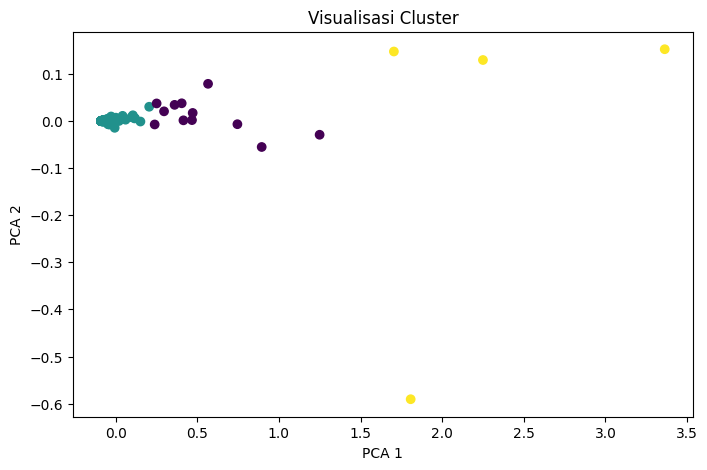

In [ ]:
#
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Visualisasi Cluster")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
df_sorted = df.sort_values(by='Cluster')
df_sorted.to_csv("/content/drive/MyDrive/projek tubes datasains/hasil_clustering.csv", index=False)

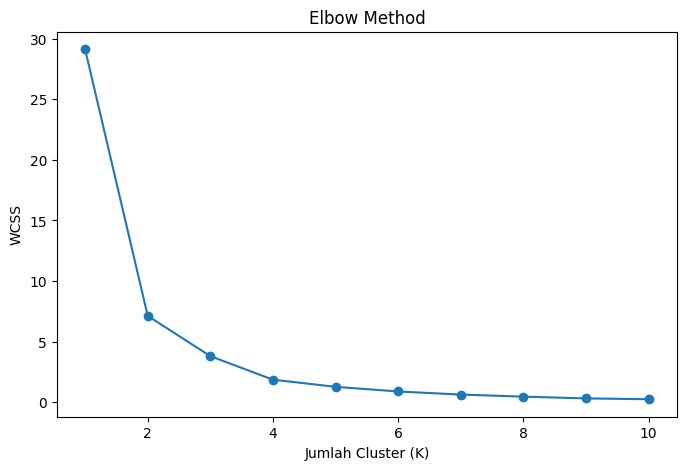

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.savefig('elbow.png', bbox_inches='tight')
plt.show()

plt.savefig('/content/drive/MyDrive/projek tubes datasains/pca.png', bbox_inches='tight')

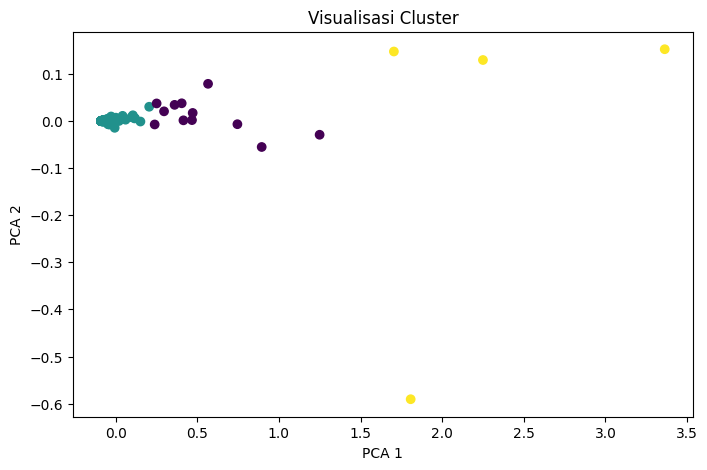

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Visualisasi Cluster")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.savefig('pca.png', bbox_inches='tight')
plt.show()
plt.savefig('/content/drive/MyDrive/projek tubes datasains/pca.png', bbox_inches='tight')